seaborn 라이브러리
-   seaborn은 파이썬에서 고급 시각화에 사용되는 라이브러리 입니다.
-   seaborn은 matploylib 라이브러리를 기반으로 구축되어 있고 판다스의 자료구조와도 밀접하게 통합되어 있습니다.

In [1]:
%pip install seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 42.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------  12.1/12.3 MB 62.7 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 51.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 9.7/9.7 MB 55.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------------ --- 2.1/2.3 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ----------------------------- ---------- 5.2/7.0 MB 24.5 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 25.6 MB/s eta 0:00:00
Note: you may need to restart the ke


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset('tips')

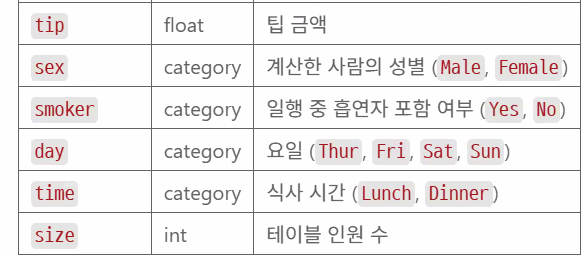

In [3]:
# 요일별(day) total_bill의 평균(mean) 계산
pivot_result = df.pivot_table(index='day',
                            values='total_bill',
                            aggfunc='mean',
                            observed=True
                            )
print(pivot_result)

      total_bill
day             
Thur   17.682742
Fri    17.151579
Sat    20.441379
Sun    21.410000


---
막대그래프


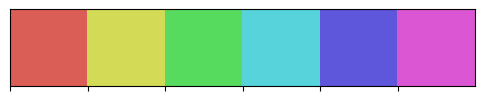

In [4]:
# 팔렛트 색상 알아보기
# 색상 명단 만들기: hls라는 색상 시스템(Hue, Lightness, Saturation)을 사용하여 서로 구분하기 쉬운 6가지 색상을 생성하고 colors 변수에 저장합니다.
colors6 = sns.color_palette('hls')
sns.palplot(colors6)    # 색상 나열하기: 저장된 6가지 색상을 수평 바 (Bar)형태로 그려서 화면에 보여줍니다. (Palette Plot)
plt.show()  # 화면에 출력

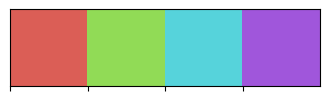

In [5]:
# 팔렛트 색상 알아보기
# 색상 명단 만들기: hls라는 색상 시스템(Hue, Lightness, Saturation)을 사용하여 서로 구분하기 쉬운 4가지 색상을 생성하고 colors 변수에 저장합니다.
colors4 = sns.color_palette('hls', 4)
sns.palplot(colors4)    # 색상 나열하기: 저장된 4가지 색상을 수평 바 (Bar)형태로 그려서 화면에 보여줍니다. (Palette Plot)
plt.show()  # 화면에 출력

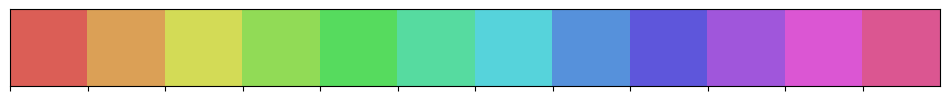

In [6]:
# 팔렛트 색상 알아보기
# 색상 명단 만들기: hls라는 색상 시스템(Hue, Lightness, Saturation)을 사용하여 서로 구분하기 쉬운 12가지 색상을 생성하고 colors 변수에 저장합니다.
colors12 = sns.color_palette('hls', 12)
sns.palplot(colors12)    # 색상 나열하기: 저장된 12가지 색상을 수평 바 (Bar)형태로 그려서 화면에 보여줍니다. (Palette Plot)
plt.show()  # 화면에 출력

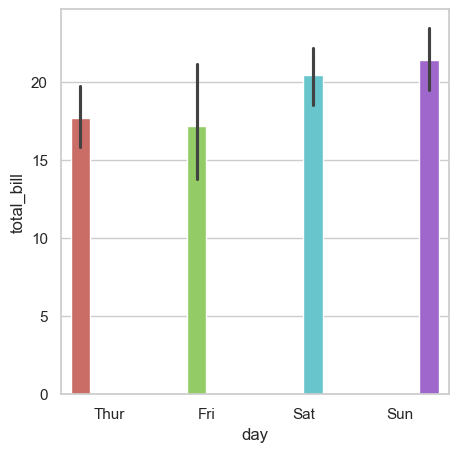

In [7]:
# 그래프 테마 설정
# style="Whitegrid" : 배경 바탕이 흰색이고, 그 위에 (회색)격자가 그려지느 스타일
# rc={"figure.figsize" : (5 : 5)}: 그래프의 전체 크기를 가로 5, 세로5 인치로 설정합니다.
sns.set_theme(style="whitegrid", rc={"figure.figsize": (5, 5)})

# 요일별 평균 지불 금액을 막대 그래프로 나타냅니다.
sns.barplot(palette='hls',  # 팔렛트 색상 지정
            data=df,        # 그래프를 그릴 때 사용할 데이터 셋(DataFram )지정
            x='day',        # x축 컬럼
            y='total_bill', # y축 컬럼 적용할 집계 함수 지정
            hue='day'   # 그룹 지정 (각 요일별로 색상을 다르게 입힙니다/)
            )
plt.show()

# hue='day'라고 설정하면, Seaborn 은 '한 요일 칸 안에 모든 요일(목, 금, 토, 일) 막대가 들어올수 있디"라고 가정하고 자리를 4등분 합니다.
# 실제로는 자기 자신의 막대 하나만 그려지지만, 나머지 3개 분량의 공간을 비워두기 때문에 막대가 1/4 크기로 얇아지는 것입니다.

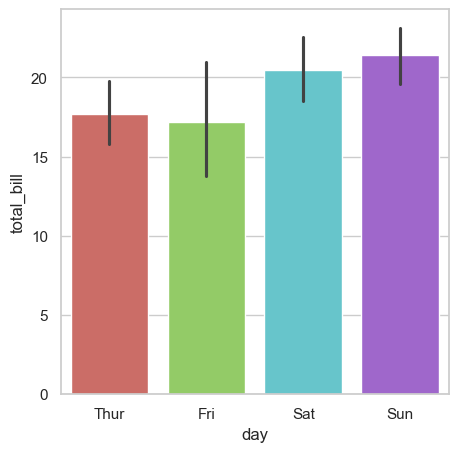

In [8]:
# Seaborn v0.13+
# 최근 버전의 seaborn은 `hue` 파라미터가 들어가면 각 항목이 들어갈 '예비공간'을 무조건 확보합니다.
# dodge=False 설정을 추가하면 확보된 예비 공간을 무시하고 막대가 해당 영역의 전체너비를 차지하게 되어
sns.set_theme(style="whitegrid", rc={"figure.figsize": (5, 5)})

# 요일별 평균 지불 금액을 막대 그래프로 나타냅니다.
sns.barplot(palette='hls',  # 팔렛트 색상 지정
            data=df,        # 그래프를 그릴 때 사용할 데이터 셋(DataFram )지정
            x='day',        # x축 컬럼
            y='total_bill', # y축 컬럼 적용할 집계 함수 지정
            hue='day',   # 그룹 지정 (각 요일별로 색상을 다르게 입힙니다/)
            dodge=False     # 막대가 전체 너비를 사용하게 합니다.
            )
plt.show()

---
Seaborn Barplot: 오차 막대(Error Bat)의 이해
1. 막대 높이의 의미
- estimator='mean': 각 범주별(예: 요일별)total_bill 데이터의 산술 평균을 나타냅니다.
---
2. 검은색 선: 오차 막대 (Error Bar) 그래프 상단의 검은색 수직 선은 통계학적으로 평균의 불확실성(변동성)을 나타냅니다.
- 신뢰구간 (Confidence Interval): 기본적으로 95% 신뢰 구간을 표시하며, "실제 모집단의 평균이 이 구간 안에 존재할 확률이 95%이다" 라는 의미입니다.
- 데이터 해석의 척도:
    - 선이 길다: 데이터의 편차가 크가나 표본(n)이 적어 평균을 확신하기 어렵습니다.
    - 선이 짧다: 데이터가 평균 주변에 밀집되어 있어 결과가 비교적 안정적입니다.
---
3. errorbar 파라미터 설정

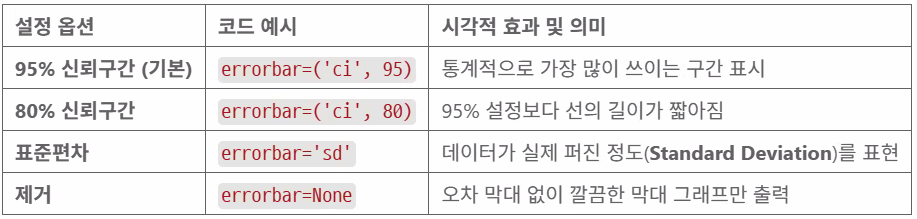

---
4. 통계적 원리 및 수식95% 신뢰 구간은 표본의 크기와 변동성을 바탕으로 아래와 같이 계산됩니다.\
(1) 신뢰 구간 (CI) 공식

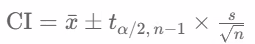

    - 표본의 개수(n)가 충분히 클 경우, t값은 약 1.96 (표준정규분포 기준)을 사용합니다.

(2) 주요 기호 설명

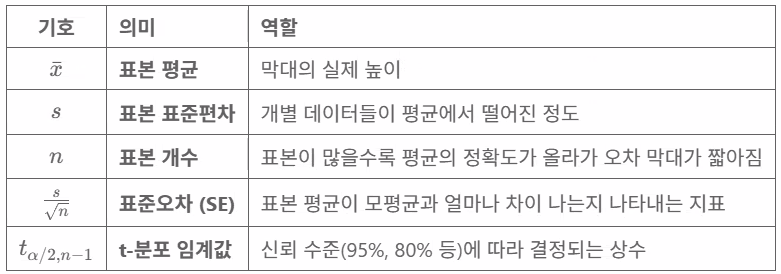

(3) 신뢰 구간(CI)공식에서 표준편차(s)가 커지거나, 표본 수(n)가 작아지면 오차 범위가 커지게 됩니다.

---

---
Seaborn에서 기본적으로 제공되는 내장 컬러 팔레트(Built-in Palette)
| 팔레트 이름       | 분위기     | 특징                        |
| ------------ | ------- | ------------------------- |
| `deep`       | 차분함, 표준 | 가장 범용적이며 신뢰감을 주는 색상       |
| `muted`      | 부드러움    | `deep`보다 채도가 낮아 파스텔 느낌을 줌 |
| `bright`     | 선명함     | 강조하고 싶을 때 사용하는 아주 밝은 색상   |
| `dark`       | 어두움     | 전체적으로 톤이 낮아 무거운 느낌을 줌     |
| `colorblind` | 범용성     | 색맹·색약인 분들도 구분하기 쉽게 설계된 색상 |

'deep' 팔레트는 별도의 설정을 하지 않았을 때 Seaborn이 가장 먼저 사용하는 표준 색상입니다.

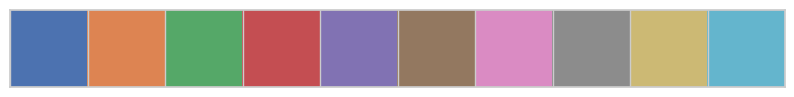

In [9]:
# 팔렛트 색상 알아보기
# Seaborn에서 'deep'은 기본적으로 제공되는 내장 컬러 팔레트(Built-in Palette)의 이름입니다.
deep_colors10 = sns.color_palette('deep')
sns.palplot(deep_colors10)
plt.show()

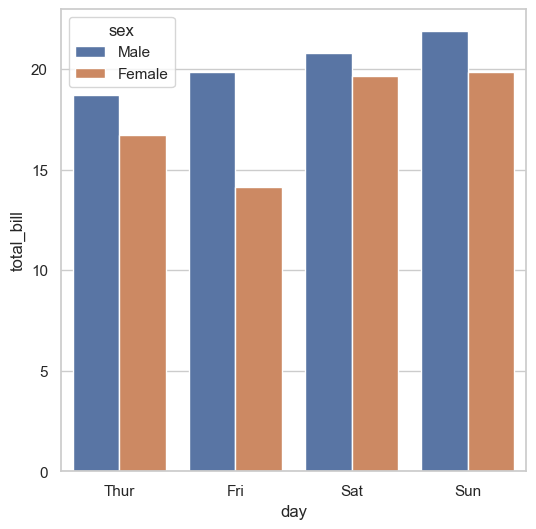

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))   # 그래프 크기를 설정

# 요일별 성별 평균 지불 금액
sns.barplot(data=df,    # df 이름
            x='day',    # x축 컬럼
            y='total_bill',  # y축 컬럼
            estimator='mean',    # y축 컬럼 적용 함수
            hue='sex',   # y축 값의 그룹핑 기중
            errorbar=None,  # 에러선 삭제
            palette='deep'
            )
plt.show()

In [11]:
# 누적 막대그래프 작성에 필요한 데이터 프레임
df2 = df.pivot_table(index='day',           # 행 위치에 들어갈 칼럼
                        columns='sex',      # 열 위치에 들어갈 컬럼
                        values='total_bill',    # 데이터로 사용할 컬럼
                        aggfunc='mean',     # 데이터 집계 함수
                        observed=False
                        )
print(df2)

sex        Male     Female
day                       
Thur  18.714667  16.715312
Fri   19.857000  14.145556
Sat   20.802542  19.680357
Sun   21.887241  19.872222


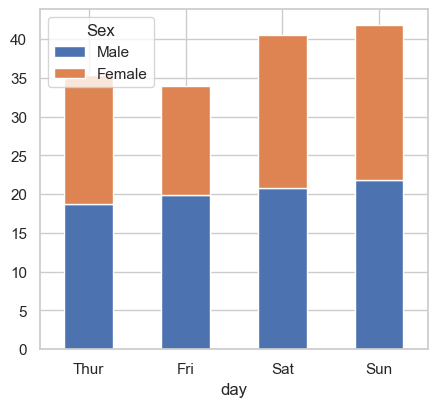

In [12]:
df2.plot.bar(stacked=True, rot=0)   # 누적 막대 그래프 작성
plt.subplots_adjust(bottom=0.2) # 그래프 전체 화면에서 아래쪽(bottom) 여백을 20% 정도 확보하라는 의미입니다.
plt.legend(loc='upper left', title='Sex')
plt.show()

---
선그래프

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# flights 데이터셋은 데이터 시각화 학습에서 가장 많이 쓰이는 예제 중 하나로 1949년부터 1960년까지의 국제선 항공기 승객 수를 기록한 데이터입니다.
df = sns.load_dataset('flights')
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


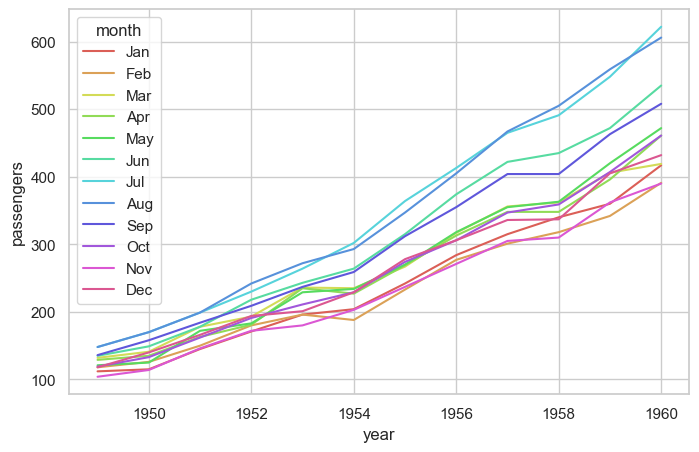

In [14]:
# 그래프 테마 설정
sns.set_theme(style="whitegrid", rc={"figure.figsize": (8, 5)})

# 팔렛트 설정
sns.set_palette('hls', 12)  # 'hls' : 색상(Hue), 밝기(Lightness), 채도(Saturation) 기반
                            # 12 : 최대 12개 색상 생성(월마다 다른 색상 지정)

# 월별, 연도별 항공기 탑승객 수
sns.lineplot(data=df,       # df이름
            x='year',       # x축 컬럼
            y='passengers',  # y축 컬럼
            hue='month'     # 그룸지정
            )
plt.show()

##### 시간 흐름(year)에 따라 선 그래프가 변화 추세 파악에 적합니다.
- 매년 항공기 탑승객의 수가 가파르게 증가하는 것을 확인할 수 있습니다.
---
상자그림

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/seoul_temp.csv')  # 월별 기온
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '../data/seoul_temp.csv'

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        365 non-null    int64  
 1   평균기온      365 non-null    float64
 2   평균강수량     365 non-null    float64
 3   평균일조시간    365 non-null    float64
 4   평균습도      365 non-null    float64
 5   평균순간최대풍속  365 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 17.2 KB


In [ ]:
# 월별로 상자그림을 작성하기 위해 날짜 컬럼에서 월만 추출합니다.
df['month'] = (df["날짜"] - 20230000) // 100 # 월 컬럼 생성
print(df.head())

         날짜  평균기온  평균강수량  평균일조시간  평균습도  평균순간최대풍속  month
0  20231231   2.1    4.7     0.6  95.5       8.3     12
1  20231230   0.6   13.1     0.0  92.0       6.9     12
2  20231229   1.3    0.0     1.8  71.0       5.7     12
3  20231228   1.2    0.0     8.1  69.5       8.0     12
4  20231227   1.5    0.0     8.2  76.6       4.7     12


In [ ]:
# 월별 평균 기온 구하기
tmp = df.groupby('month').mean()
print(tmp)

               날짜       평균기온      평균강수량    평균일조시간       평균습도  평균순간최대풍속
month                                                                 
1      20230116.0  -1.522581   1.545161  6.158065  63.303226  8.038710
2      20230214.5   2.300000   0.035714  7.078571  58.900000  7.475000
3      20230316.0   9.780645   0.338710  7.735484  51.241935  8.612903
4      20230415.5  13.800000   3.230000  6.076667  59.933333  9.546667
5      20230516.0  19.522581   5.019355  7.600000  62.493548  8.893548
6      20230615.5  23.383333   6.520000  6.503333  72.433333  7.970000
7      20230716.0  26.706452  14.835484  4.712903  81.074194  8.712903
8      20230816.0  27.187097   9.616129  5.035484  76.351613  7.951613
9      20230915.5  23.663333   4.483333  5.236667  73.483333  6.980000
10     20231016.0  15.793548   1.000000  6.732258  66.477419  6.816129
11     20231115.5   6.796667   2.730000  5.730000  64.503333  9.203333
12     20231216.0   1.116129   2.770968  4.587097  69.348387  7.929032


In [ ]:
# 평균기온 순위 구하기
rank = tmp['평균기온'].rank()
print(rank)

month
1      1.0
2      3.0
3      5.0
4      6.0
5      8.0
6      9.0
7     11.0
8     12.0
9     10.0
10     7.0
11     4.0
12     2.0
Name: 평균기온, dtype: float64


In [ ]:
# 0 부터 시작하도록 조정합니다
rank = rank - 1
print(rank)
print(type(rank))

month
1      0.0
2      2.0
3      4.0
4      5.0
5      7.0
6      8.0
7     10.0
8     11.0
9      9.0
10     6.0
11     3.0
12     1.0
Name: 평균기온, dtype: float64
<class 'pandas.Series'>


In [ ]:
# 정수형 리스트로 변환
rank = rank.astype(int).to_list()
print(rank)

[0, 2, 4, 5, 7, 8, 10, 11, 9, 6, 3, 1]


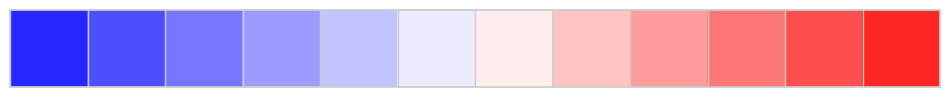

In [ ]:
# 'bwr' : Blue - White - Red 컬러맵 사용
bwr_colors12 = sns.color_palette('bwr', 12)
sns.palplot(bwr_colors12)
plt.show()

In [ ]:
# 그래프 테마 설정
sns.set_theme(style="white", rc={"figure.figsize": (7 ,4)})

# 팔레트 색 선택 및 순서 변경
mycolor = sns.color_palette('bwr', 12)  # 'bwr' : Blue - White - Red 컬러맵 사용
                                        # 12 : 총 12개의 색상 생성
print(mycolor)

[(0.14901960784313725, 0.14901960784313725, 1.0), (0.3058823529411765, 0.3058823529411765, 1.0), (0.4627450980392157, 0.4627450980392157, 1.0), (0.611764705882353, 0.611764705882353, 1.0), (0.7686274509803921, 0.7686274509803921, 1.0), (0.9254901960784314, 0.9254901960784314, 1.0), (1.0, 0.9254901960784314, 0.9254901960784314), (1.0, 0.7686274509803921, 0.7686274509803921), (1.0, 0.611764705882353, 0.611764705882353), (1.0, 0.46274509803921593, 0.46274509803921593), (1.0, 0.3058823529411765, 0.3058823529411765), (1.0, 0.14901960784313728, 0.14901960784313728)]


In [ ]:
print(pd.Series(mycolor)[rank]) # 색상 리스트를 rank 순서로 재정렬한 경과를 출력

0     (0.14901960784313725, 0.14901960784313725, 1.0)
2       (0.4627450980392157, 0.4627450980392157, 1.0)
4       (0.7686274509803921, 0.7686274509803921, 1.0)
5       (0.9254901960784314, 0.9254901960784314, 1.0)
7       (1.0, 0.7686274509803921, 0.7686274509803921)
8         (1.0, 0.611764705882353, 0.611764705882353)
10      (1.0, 0.3058823529411765, 0.3058823529411765)
11    (1.0, 0.14901960784313728, 0.14901960784313728)
9     (1.0, 0.46274509803921593, 0.46274509803921593)
6       (1.0, 0.9254901960784314, 0.9254901960784314)
3         (0.611764705882353, 0.611764705882353, 1.0)
1       (0.3058823529411765, 0.3058823529411765, 1.0)
dtype: object


In [ ]:
# 색상 리스트를 rank 순서로 재정렬한 결과를 리스트로 반환
mycolor = pd.Series(mycolor)[rank].to_list()
print(mycolor)  # 기온이 낮은 달일술록 파란색 계열이 적용되고 기온이 높을수롤  빨간색 계일이 적용되도록 설정합니다.

[(0.14901960784313725, 0.14901960784313725, 1.0), (0.4627450980392157, 0.4627450980392157, 1.0), (0.7686274509803921, 0.7686274509803921, 1.0), (0.9254901960784314, 0.9254901960784314, 1.0), (1.0, 0.7686274509803921, 0.7686274509803921), (1.0, 0.611764705882353, 0.611764705882353), (1.0, 0.3058823529411765, 0.3058823529411765), (1.0, 0.14901960784313728, 0.14901960784313728), (1.0, 0.46274509803921593, 0.46274509803921593), (1.0, 0.9254901960784314, 0.9254901960784314), (0.611764705882353, 0.611764705882353, 1.0), (0.3058823529411765, 0.3058823529411765, 1.0)]


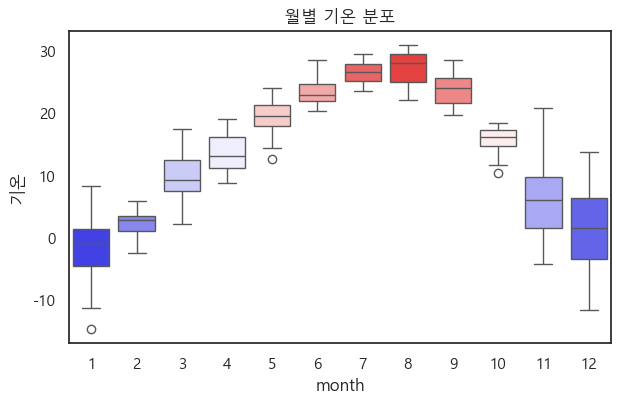

In [ ]:
# 월별 기온 분포를 상자 그림으로 작성
plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

sns.boxplot(data=df,    # df 이름
            x='month',  # x축 컬럼
            y='평균기온', # y축 컬럼
            hue='month',    # 그룸 지정
            legend=None,    # 범례 표시 안 함
            palette=mycolor # 팔레트 지정
            ).set(title='월별 기온 분포')

plt.ylabel('기온')  # y 축 레이블
plt.subplots_adjust(bottom=0.1) # 하단 여백
plt.show()

---
히트맵(Heatmap)은 데이터의 값을 색상의 강도(밝기.색상)로 표현하는 시각화 그래프입니다.
- 마치 열화상 카메라로 온도를 측정했을 때 뜨거운 곳은 붉게, 차가운 곳은 푸르게 표시되는 것과 같은 원리라고 이해하면 쉽습니다.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

flights = sns.load_dataset('flights')
print(flights.head())

   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121


In [ ]:
# 피벗 테이블 생성
df = flights.pivot_table(index='month', # 행 위치에 들어갈 칼럼
                        columns='year',  # 열 위치에 들어갈 칼럼
                        values='passengers', # 데이터로 사용할 컬럼
                        aggfunc='mean',     # 데이터 집계 함수
                        observed=False
)
print(df.head())

year    1949   1950   1951   1952   1953   1954   1955   1956   1957   1958  \
month                                                                         
Jan    112.0  115.0  145.0  171.0  196.0  204.0  242.0  284.0  315.0  340.0   
Feb    118.0  126.0  150.0  180.0  196.0  188.0  233.0  277.0  301.0  318.0   
Mar    132.0  141.0  178.0  193.0  236.0  235.0  267.0  317.0  356.0  362.0   
Apr    129.0  135.0  163.0  181.0  235.0  227.0  269.0  313.0  348.0  348.0   
May    121.0  125.0  172.0  183.0  229.0  234.0  270.0  318.0  355.0  363.0   

year    1959   1960  
month                
Jan    360.0  417.0  
Feb    342.0  391.0  
Mar    406.0  419.0  
Apr    396.0  461.0  
May    420.0  472.0  


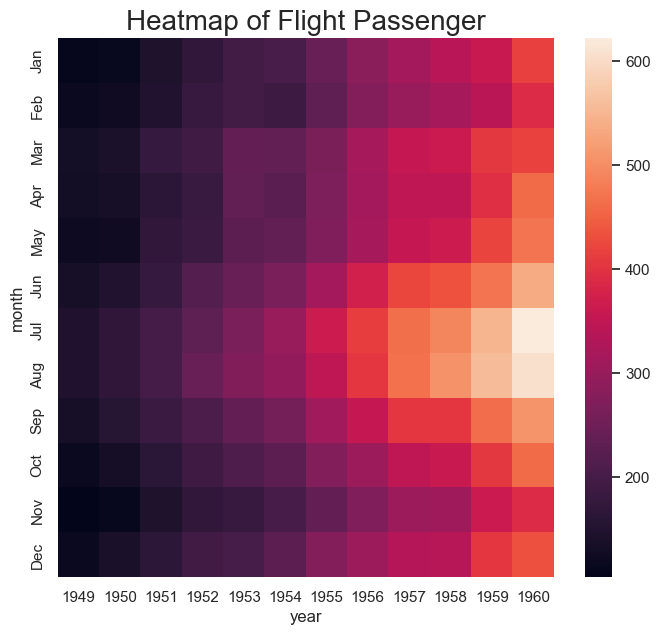

In [ ]:
# 히트맵 작성
sns.set_theme(rc={'figure.figsize': (8, 7)})
sns.heatmap(df).set_title('Heatmap of Flight Passenger', fontsize=20)
plt.show()

- 색이 밝을 수록 탑승객 수가 많고 색이 어두울 수록 탑승객 수가 적습니다.
- 해가 갈 수록 색이 밝아지는 경향을 볼 수 있습니다.
- 특히7,8월의 탑승객 수 변화는 다른 달과 비교했을때 증가 속도가 더 빠릅니다.
- 이를 통해 7월과 8월이 성수기라고 해석할 수 있습니다.